# Computational Mathematics
## Problem sheet 1 HT
## 2026-2-10
## Lucy Norman (<lucy.norman@worc.ox.ac.uk>)
## Worcester College


***
### Question 3a

In [1]:
import matplotlib.pyplot as plt

In [2]:
def sequence(n):
    return 2**(-n)

In [3]:
xs=[i for i in range(1, 101)]
ys=[sequence(x) for x in xs]

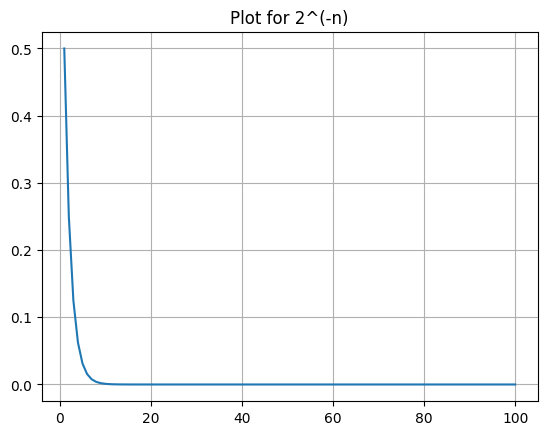

In [4]:
plt.grid()
plt.title("Plot for 2^(-n)")
plt.plot(xs,ys)

In [5]:
plt.show()

In [6]:
pass


***
### Question 3b.


In [7]:
import matplotlib.pyplot as plt

In [8]:
def sequence(n):
    return 1/(n+1)

In [9]:
xs=[i for i in range(1, 101)]
ys=[sequence(x) for x in xs]

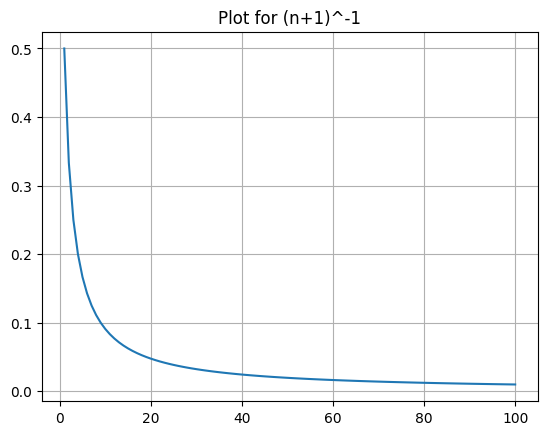

In [10]:
plt.grid()
plt.title("Plot for (n+1)^-1")
plt.plot(xs,ys)

In [11]:
plt.show()

In [12]:
pass


***
### Question 3c.


In [13]:
import matplotlib.pyplot as plt
import math

In [14]:
def sequence(n):
    return math.log(2**(-2**n),10)

In [15]:
xs=[i for i in range(1, 11)]
ys=[sequence(x) for x in xs]

Text(0, 0.5, 'Log base 10')

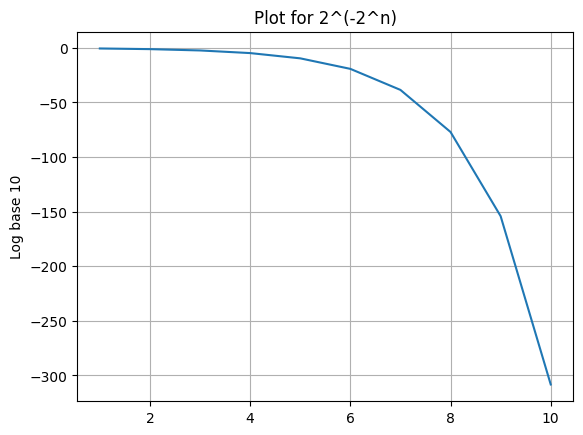

In [16]:
plt.grid()
plt.title("Plot for 2^(-2^n)")
plt.plot(xs,ys)
plt.ylabel("Log base 10")

In [17]:
plt.show()

In [18]:
pass

<span style="color: SeaGreen; font-size: 32px;">Q3</span>

<span style="color: SeaGreen; font-size: 24px;">

Great stuff.

For (b), when both the order of convergence and rate are 1, we would say it is sublinear convergence.

For (c), when the order of convergence is 2 and rate is in $(0, \infty)$, we would say it is quadratic convergence.

</span>

<span style="color: SeaGreen; font-size: 32px;">Q4</span>

<span style="color: SeaGreen; font-size: 24px;">

All correct, great stuff.

Worth noting that for (a) proving that the Lipschitz constant is $<1$ actually isn't sufficient, showing it is also endomorphic is required.

</span>


***
### Question 5b.


In [19]:
import mpmath as mp

In [20]:
mp.mp.dps=100

In [21]:
pi_val=mp.pi
sum=mp.mpf(0)

In [22]:
for k in range (0, 10001):
    term = (-1)**k / mp.mpf(2*k + 1)
    sum+=term

In [23]:
result=mp.mpf(4*sum)
e_1=abs(result-pi_val)

In [24]:
result=result-4/mp.mpf(10001*2+1)
e_2=abs(result-pi_val)

In [25]:
result=result+4/mp.mpf(10002*2+1)
e_3=abs(result-pi_val)

In [26]:
q=mp.log(e_2/e_3)/mp.log(e_1/e_2)

In [27]:
print("q is",q)

q is 0.9999000249945843123523714907359009089770693145957966411467122531647631995532946505081216005477199894


In [28]:
M=e_2/e_1**q

In [29]:
print("M is", M)

M is 0.99897972201023220997425474859295312179295059129178768722261891082089016274244234371259842098928492


In [30]:
pass


***
### Question 5c.


In [31]:
import mpmath as mp
import matplotlib.pyplot as plt

In [32]:
mp.mp.dps=100

In [33]:
pi_val=mp.pi

In [34]:
a=[]#initial sequence
sum=mp.mpf(0)
for k in range(0, 10004):
    sum += (-1)**k /mp.mpf(2*k+1)
    a.append(mp.mpf(4)*sum)

In [35]:
a1=[] #aitken acceleration

In [36]:
for k in range(0, 10002):
    a1.append(a[k] - (a[k+1]-a[k])**2/(a[k+2]-2*a[k+1]+a[k]))

In [37]:
a2=[] #iterated acceleration

In [38]:
for k in range(0, 10000):
    a2.append(a1[k] - (a1[k+1]-a1[k])**2/(a1[k+2]-2*a1[k+1]+a1[k]))

In [39]:
#errors
e0=[abs(a[i]-pi_val) for i in range (10000)]
e1=[abs(a1[i]-pi_val) for i in range (10000)]
e2=[abs(a2[i]-pi_val) for i in range (10000)]

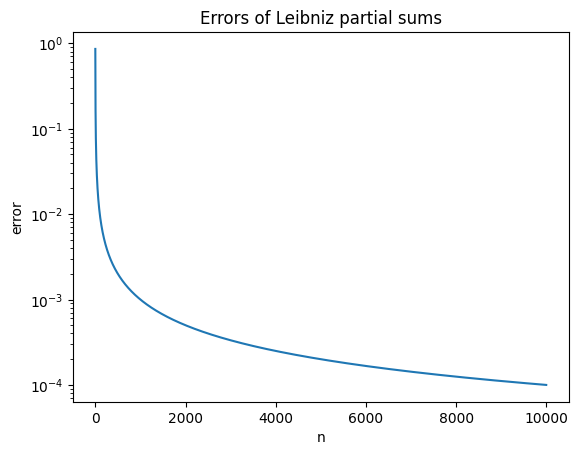

In [40]:
#original errors
plt.figure()
plt.semilogy(range(10000), e0)
plt.xlabel("n")
plt.ylabel("error")
plt.title("Errors of Leibniz partial sums")
plt.show()

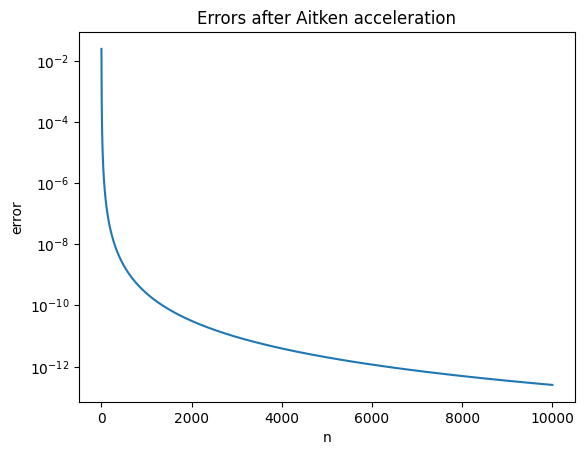

In [41]:
#aitken-accelerated errors
plt.figure()
plt.semilogy(range(10000), e1)
plt.xlabel("n")
plt.ylabel("error")
plt.title("Errors after Aitken acceleration")
plt.show()

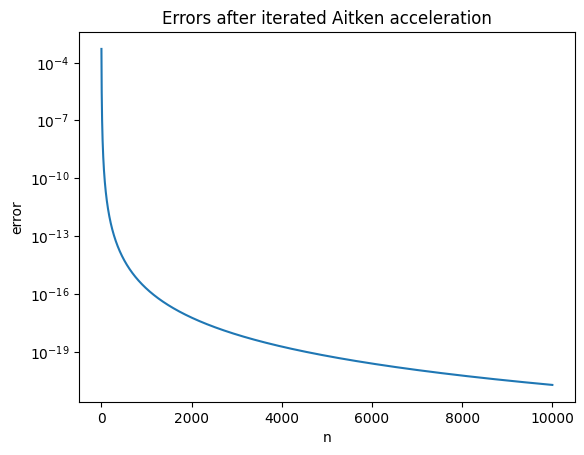

In [42]:
#iterated aitken errors
plt.figure()
plt.semilogy(range(10000), e2)
plt.xlabel("n")
plt.ylabel("error")
plt.title("Errors after iterated Aitken acceleration")
plt.show()

In [43]:
pass


***
### Question 5d.


In [44]:
import mpmath as mp
import matplotlib.pyplot as plt

In [45]:
mp.mp.dps=100

In [46]:
pi_val=mp.pi

In [47]:
a=[]#initial sequence
sum=mp.mpf(0)
for k in range(0, 10004):
    sum += (-1)**k /mp.mpf(2*k+1)
    a.append(mp.mpf(4)*sum)

In [48]:
a1=[] #aitken acceleration

In [49]:
for k in range(0, 10002):
    a1.append(a[k] - (a[k+1]-a[k])**2/(a[k+2]-2*a[k+1]+a[k]))

In [50]:
a2=[] #iterated acceleration

In [51]:
for k in range(0, 10000):
    a2.append(a1[k] - (a1[k+1]-a1[k])**2/(a1[k+2]-2*a1[k+1]+a1[k]))

In [52]:
#errors
e0=[abs(a[i]-pi_val) for i in range (10000)]
e1=[abs(a1[i]-pi_val) for i in range (10000)]
e2=[abs(a2[i]-pi_val) for i in range (10000)]

In [53]:
def estimation(e_1, e_2, e_3):
    q=mp.log(e_2/e_3)/mp.log(e_1/e_2)
    q_str =mp.nstr(q, 10)
    print("q is ~"+q_str)
    M=e_2/e_1**q
    print("M is ~"+ mp.nstr(M, 10))

In [54]:
print("for aitken:")
estimation(e1[2000], e1[2001], e1[2002])

for aitken:
q is ~0.9995008737
M is ~0.9865187059


In [55]:
print("\nfor accelerated aitken:")
estimation(e2[2000], e2[2001], e2[2002])


for accelerated aitken:
q is ~0.9995011229
M is ~0.9779526168


In [56]:
pass

I feel as though something has gone wrong here.

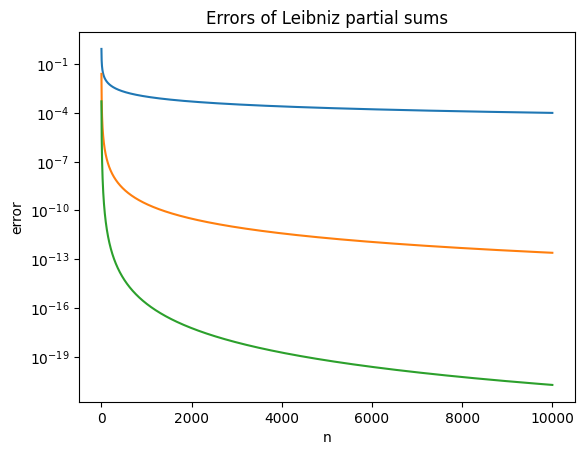

In [57]:
#original errors
plt.figure()

plt.plot(range(10000), e0)

plt.plot(range(10000), e1)

plt.plot(range(10000), e2)

plt.yscale("log")

plt.xlabel("n")
plt.ylabel("error")
plt.title("Errors of Leibniz partial sums")
plt.show()

<span style="color: SeaGreen; font-size: 32px;">Q5</span>

<span style="color: SeaGreen; font-size: 24px;">

I don't think anything went wrong!

The conclusion is that they are all sublinear. We see that each application of acceleration is improving the error by about 8 orders of magnitude, with little effect on how it's converging (given by the above plot).


</span>